# Test `Model.xlsm` scraping and execution

This notebook exercises each major workbook-backed step for Sandra's `Model.xlsm` flow:

1. start a questionnaire session and scrape the generated questions
2. submit answer letters and read the workbook-generated investor profile
3. run the optimizer and MVP flow
4. display the workbook-generated summary table and charts

The control knobs live in Python variables instead of notebook input widgets.

## Root workbook note

Set `USE_SOURCE_WORKBOOK = True` to operate directly on the project-root workbook at `Model.xlsm`.

That avoids creating a fresh copied workbook for each notebook run, which can help reduce repeated workbook-level permission or trust prompts.

Keep in mind this writes directly into the root workbook, so the notebook is best used sequentially rather than for parallel sessions.

In [1]:
from pathlib import Path
import importlib

import pandas as pd
from IPython.display import Image, Markdown, display

import model_workflow as mw
importlib.reload(mw);

In [2]:
# Notebook knobs
WORKBOOK_PATH = Path("Model.xlsm").resolve()
OUTPUT_DIR = Path("notebook_outputs").resolve()
USE_SOURCE_WORKBOOK = True
VISIBLE = False

# Edit these before running the answer and optimizer cells.
SAMPLE_ANSWERS = {
    "q1": "a",
    "q2": "d",
    "q3": "a",
    "q4": "a",
    "q5": "a",
    "q6": "a",
    "q7": "a",
    "q8": "a",
    "q9": "c",
    "q10": "a",
}
ALLOW_SHORT_SELLING = False

In [3]:
runner = mw.ModelWorkbookRunner()
contract = runner.contract

display(
    pd.DataFrame(
        [
            {"field": "advisor_name", "value": mw.ADVISOR_NAME},
            {"field": "workbook_path", "value": str(WORKBOOK_PATH)},
            {"field": "output_dir", "value": str(OUTPUT_DIR)},
            {"field": "use_source_workbook", "value": USE_SOURCE_WORKBOOK},
            {"field": "questionnaire_sheet", "value": contract.questionnaire_sheet},
            {"field": "optimizer_sheet", "value": contract.optimizer_sheet},
            {"field": "calculator_sheet", "value": contract.calculator_sheet},
            {"field": "summary_range", "value": contract.summary_range},
            {"field": "chart_names", "value": ", ".join(contract.chart_names)},
        ]
    )
)

,field,value
0,advisor_name,Sandra
1,workbook_path,/Users/gitaalekhyapaul/Documents/[Local] BMD53...
2,output_dir,/Users/gitaalekhyapaul/Documents/[Local] BMD53...
3,use_source_workbook,True
4,questionnaire_sheet,1_Questionnaire
5,optimizer_sheet,12_Optimizer
6,calculator_sheet,2_MVP_Calculator
7,summary_range,A18:D28
8,chart_names,"MVP_FrontierChart, OptimalWeight_Chart"


## 1. Generate and scrape the questionnaire

In [4]:
start_state = runner.start_questionnaire_session(
    workbook_path=WORKBOOK_PATH,
    output_dir=OUTPUT_DIR,
    visible=VISIBLE,
    use_source_workbook=USE_SOURCE_WORKBOOK,
)
start_payload = runner.serialize_start_payload(start_state)

display(pd.Series({
    "advisor_name": start_payload["advisor_name"],
    "session_id": start_payload["session_id"],
    "source_workbook_path": start_payload["source_workbook_path"],
    "workbook_copy": start_payload["workbook_copy"],
    "use_source_workbook": start_payload["use_source_workbook"],
    "metadata_path": start_payload["metadata_path"],
}).to_frame("value"))

questions_df = pd.DataFrame(
    {
        "key": question["key"],
        "row": question["row"],
        "prompt": question["prompt"],
        "options": "\n".join(question["options"]),
        "answer_letters": ", ".join(question["option_letters"]),
    }
    for question in start_payload["questions"]
)
questions_df

,value
advisor_name,Sandra
session_id,8114555a382f419189b261665e0c5152
source_workbook_path,/Users/gitaalekhyapaul/Documents/[Local] BMD53...
workbook_copy,/Users/gitaalekhyapaul/Documents/[Local] BMD53...
use_source_workbook,True
metadata_path,/Users/gitaalekhyapaul/Documents/[Local] BMD53...


,key,row,prompt,options,answer_letters
0,q1,9,When you receive conflicting investment advice...,(a) Default to the most conservative advice ...,"a, b, c, d"
1,q2,10,Which of the following do you prefer? (All hav...,(a) $500 guaranteed → A = 8.00\n(b) A 50%...,"a, b, c, d"
2,q3,11,"You receive a $20,000 bonus. You would:",(a) Keep it in savings → A = 8.00\n(b) Pa...,"a, b, c, d, e"
3,q4,12,"When making investment decisions, you:",(a) Stick with what I know is safe → A = 8...,"a, b, c, d"
4,q5,13,What is the largest 1-YEAR loss you could acce...,(a) 0% – 5% → A = 9.00\n(b) 5% – 15% → ...,"a, b, c, d, e"
5,q6,14,The central bank has just raised rates sharply...,(a) Move to short-term cash equivalents → ...,"a, b, c, d"
6,q7,15,"If you had to invest 100% in stocks, which of ...",(a) Only blue-chip domestic stocks → A = 6...,"a, b, c, d"
7,q8,16,"Do you anticipate any major expenses (home, we...","(a) Yes, within 1 year → A = 8.00\n(b) Ye...","a, b, c, d, e"
8,q9,17,What is your minimum acceptable REAL return (a...,(a) Just beating inflation is enough → A =...,"a, b, c, d"
9,q10,18,Your age range:,(a) Under 25 → A = 3.00\n(b) 25 – 40 → ...,"a, b, c, d, e"


## 2. Submit answer letters and read the workbook-generated investor profile

Update `SAMPLE_ANSWERS` in the knobs cell before running this.

In [5]:
answered_state = runner.submit_answers(
    session_id=start_state.session_id,
    answers=SAMPLE_ANSWERS,
    output_dir=OUTPUT_DIR,
    visible=VISIBLE,
)
profile_payload = runner.serialize_profile_payload(answered_state)

display(pd.Series({
    "advisor_name": profile_payload["advisor_name"],
    "session_id": profile_payload["session_id"],
    "investor_profile": profile_payload["investor_profile"],
    "next_step": profile_payload["next_step"],
}).to_frame("value"))

display(Markdown(profile_payload["creative_profile_message"]))

,value
advisor_name,Sandra
session_id,8114555a382f419189b261665e0c5152
investor_profile,Moderately Conservative
next_step,Ask the user whether they want short selling (...


Sandra's workbook-generated assessment classifies the investor profile as Moderately Conservative. This points to a preference for capital preservation, steadier portfolio behavior, and a lower overall risk budget. The next step is to decide whether short selling should be enabled for the optimizer run.

## 3. Run the optimizer and chart export

Set `ALLOW_SHORT_SELLING` in the knobs cell before running this.

In [6]:
final_state = runner.run_mvp(
    session_id=start_state.session_id,
    allow_short_selling=ALLOW_SHORT_SELLING,
    output_dir=OUTPUT_DIR,
    visible=VISIBLE,
)
final_payload = runner.serialize_final_payload(final_state)

display(pd.Series({
    "advisor_name": final_payload["advisor_name"],
    "session_id": final_payload["session_id"],
    "allow_short_selling": final_payload["allow_short_selling"],
    "investor_profile": final_payload["investor_profile"],
    "summary_range": final_payload["summary_range"],
}).to_frame("value"))

summary_df = pd.DataFrame(final_payload["summary_table_records"])
summary_df

,value
advisor_name,Sandra
session_id,8114555a382f419189b261665e0c5152
allow_short_selling,False
investor_profile,Moderately Conservative
summary_range,A18:D28


,Fund,Category,Weight,Ann. Return (μ)
0,Amova SG Bond,SG Bond,0.00,0.0233
1,BK World Gold,Commodity (Gold),0.15,0.2654
2,ES Asian Bond,Asian Bond,0.00,-0.0638
3,ES Asian Equity,Asian Equity,0.15,0.0685
4,Fid World,Global Equity,0.10,0.0750
5,Fid America,US Equity,0.10,0.0767
6,Fid EM,Emerging Mkts,0.10,0.0496
7,LionGlobal SG,SG Equity,0.40,0.1524
8,Manulife AP REIT,Asia Pacific REITs,0.00,-0.0868
9,PIMCO Income,Global Bond,0.00,0.0298


## 4. Display exported workbook charts

### MVP_FrontierChart

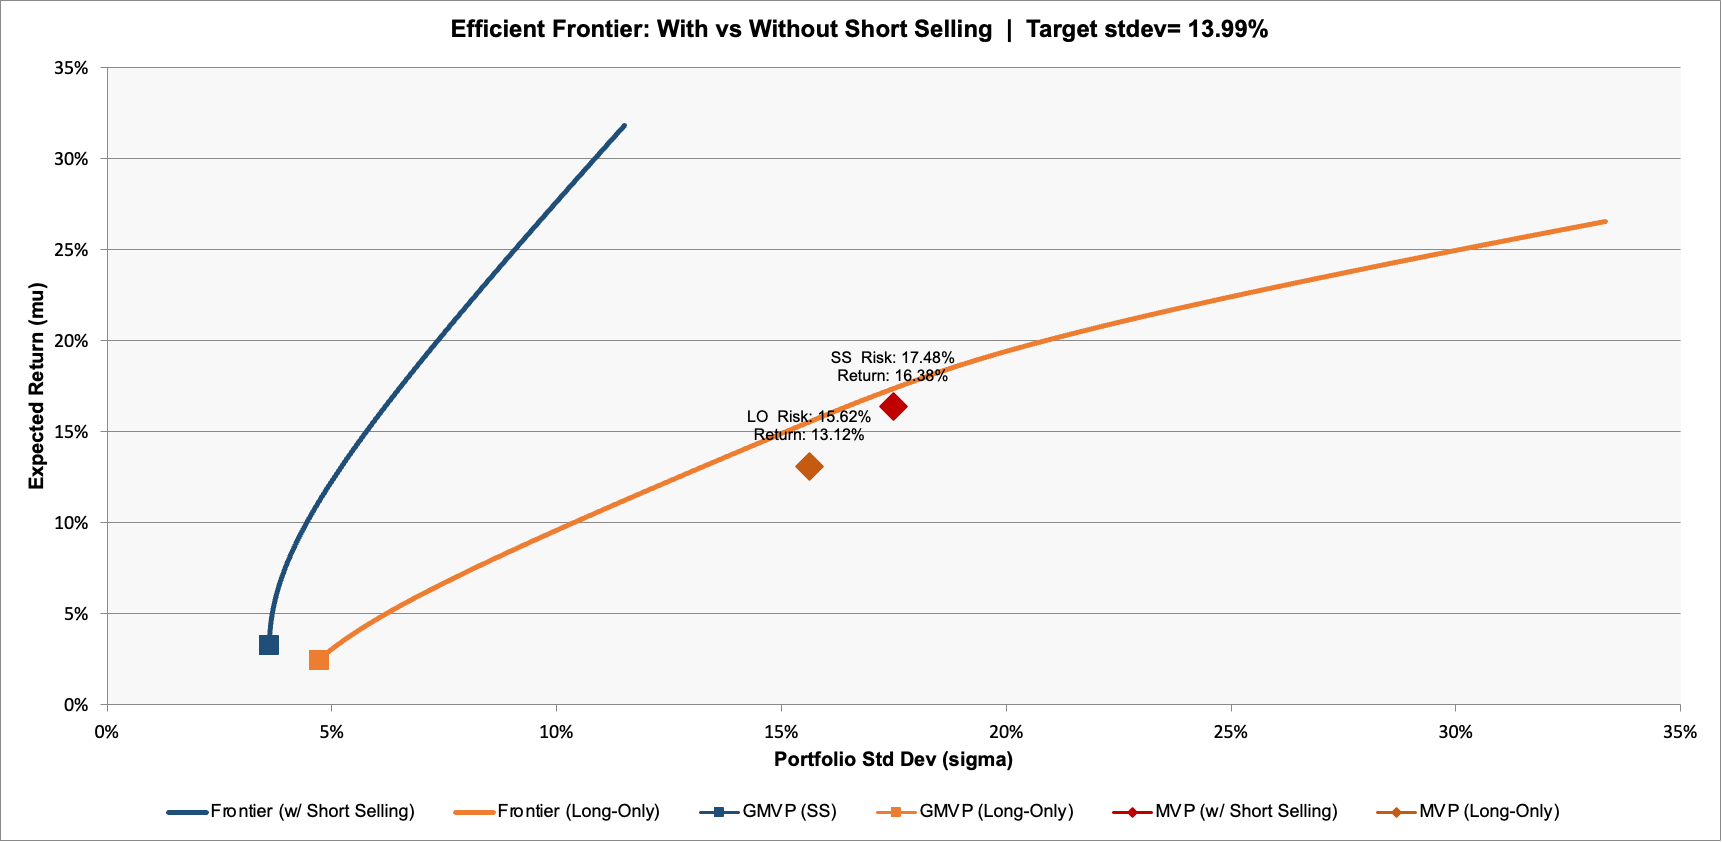

### OptimalWeight_Chart

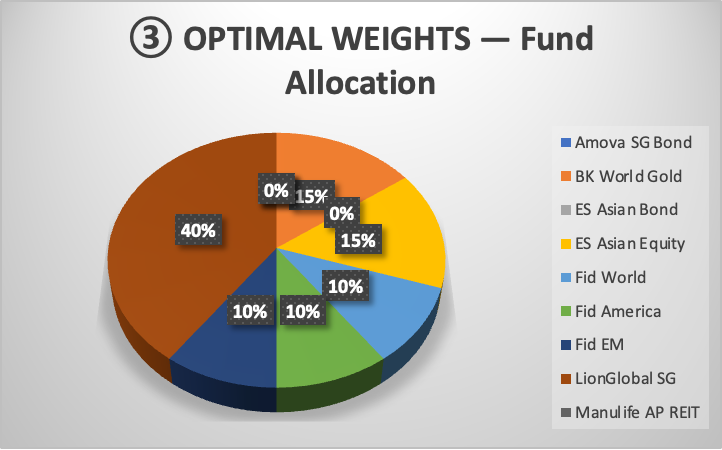

In [7]:
for chart_name, chart_path in final_payload["chart_paths"].items():
    display(Markdown(f"### {chart_name}"))
    display(Image(filename=chart_path))

## 5. Reload the saved session metadata

This is useful when you want to inspect what the workflow persisted between notebook cells.

In [8]:
reloaded_state = runner.load_session_state(
    session_id=start_state.session_id,
    output_dir=OUTPUT_DIR,
)

display(pd.Series({
    "session_id": reloaded_state.session_id,
    "source_workbook_path": reloaded_state.source_workbook_path,
    "workbook_copy": reloaded_state.workbook_copy,
    "use_source_workbook": reloaded_state.use_source_workbook,
    "metadata_path": reloaded_state.metadata_path,
    "status": reloaded_state.status,
}).to_frame("value"))

,value
session_id,8114555a382f419189b261665e0c5152
source_workbook_path,/Users/gitaalekhyapaul/Documents/[Local] BMD53...
workbook_copy,/Users/gitaalekhyapaul/Documents/[Local] BMD53...
use_source_workbook,True
metadata_path,/Users/gitaalekhyapaul/Documents/[Local] BMD53...
status,completed
